# Quick Overview: Iterative Proportional Election

This notebook shows the complete procedure of an iterative proportional election using a small, hand-verifiable example (5 constituencies, 3 parties).

**Procedure:**
1. Round 1 — no party reaches the required vote share
2. Round 2 — injected probabilities, still no winner
3. Coalition formation — two parties form a coalition and win
4. Seat distribution and constituency assignment

For real voting data: [`federal_election.ipynb`](federal_election.ipynb)  
For details on individual steps: the respective step-by-step notebooks ([Overview](../../docs/source/en/einfuehrung.md))

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display

from ipres import (
    Election, ElectionConfig, ConstituenciesConfig,
    ElectionEvaluator, VoteMatrixAnalyzer,
    SuperMajorityMargin, MarginUnit,
)

cc = ConstituenciesConfig.from_dataframe(pd.DataFrame({
    'constituency_name': ['C1', 'C2', 'C3', 'C4', 'C5'],
    'constituency_size': [100_000] * 5,
}))

config = ElectionConfig(
    constituencies_config=cc,
    participating_parties=['A', 'B', 'C'],
    parliament_majority_margin=SuperMajorityMargin(5.0, MarginUnit.PERCENT),
    seed=42,
)

election = Election(electionConfig=config)

print(f"Parliamentary seats:  {config.parliamentarySeats}")
print(f"Governing seats:      {config.getParliamentMajoritySeats()}")
print(f"Ballot threshold:     {config.getBallotMajorityPercent():.1f} %  (minimum required to win a round directly)")

Parliamentary seats:  10
Governing seats:      6
Ballot threshold:     52.0 %  (minimum required to win a round directly)


---

## Round 1

Specific vote counts are injected to make the results hand-verifiable.

| Constituency | A  | B  | C  | Σ   |
|--------------|----|----|-----|-----|
| C1           | 48 | 32 | 20 | 100 |
| C2           | 50 | 30 | 20 | 100 |
| C3           | 46 | 34 | 20 | 100 |
| C4           | 51 | 29 | 20 | 100 |
| C5           | 49 | 31 | 20 | 100 |
| **Σ**        | **244** | **156** | **100** | **500** |
| **Share**    | **48.8 %** | **31.2 %** | **20.0 %** | |

No party reaches the ballot threshold → no winner. C is eliminated (A+B cover > ⅔ of all votes).

,Stimmen,Prozent
A,244,48.80%
B,156,31.20%
C,100,20.00%


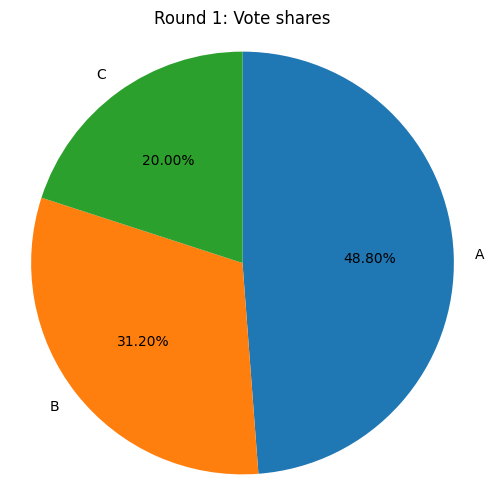

Winner? False


In [2]:
votes = {
    'C1': {'A': 48, 'B': 32, 'C': 20},
    'C2': {'A': 50, 'B': 30, 'C': 20},
    'C3': {'A': 46, 'B': 34, 'C': 20},
    'C4': {'A': 51, 'B': 29, 'C': 20},
    'C5': {'A': 49, 'B': 31, 'C': 20},
}

round1 = election.start(votes=votes)
display(round1.show_results_table(styler=True))
fig = round1.plot_vote_share_pie(title="Round 1: Vote shares")
display(fig)
plt.close(fig)

print(f"Winner? {election.hasWinner()}")

---

## Round 2 — Injected Probabilities

C is eliminated. We specify how C's voters are expected to vote in the next round.
The injected probabilities set the vote shares directly and are normalised automatically.
No party reaches the ballot threshold in this round either.

Remaining parties: ['A', 'B']


,Stimmen,Prozent
B,"142,377",51.07%
A,"136,415",48.93%


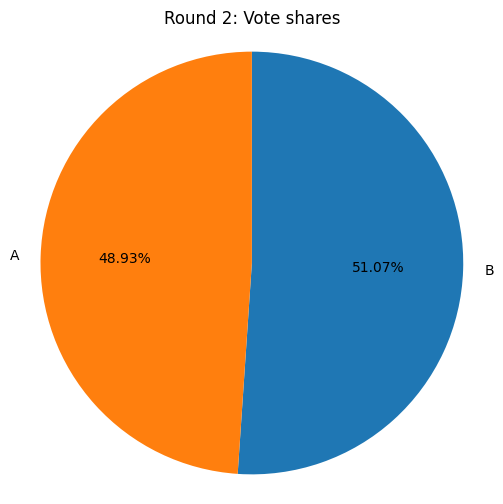

Winner? False


In [3]:
r2input = round1.getNextRoundInput()
print(f"Remaining parties: {list(r2input.contestants.keys())}")

# C voters split: most to A, minority to B
r2input.probabilities = {"A": 49, "B": 51}

round2 = election.runNextIteration(r2input)
display(round2.show_results_table(styler=True))
fig = round2.plot_vote_share_pie(title="Round 2: Vote shares")
display(fig)
plt.close(fig)

print(f"Winner? {election.hasWinner()}")

---

## Coalition Formation

No party reaches the required majority. A and B form a coalition.
The votes of both parties are combined — the coalition exceeds the ballot threshold.

In [4]:
round2.formCoalition("A+B", ["A", "B"])

display(round2.show_results_table(styler=True))
fig = round2.plot_vote_share_pie(title="Round 2 after coalition formation")
display(fig)
plt.close(fig)

print(f"Winner? {election.hasWinner()}")
print(f"Winner: {election.getWinner().name}")

ValueError: At least two contestants must compete. All contestants cannot form a single coalition.

---

## Seat Distribution

The `ElectionEvaluator` automatically runs all three evaluation steps:
seat allocation → constituency count determination → constituency assignment.

Details: [`election_evaluation.ipynb`](election_evaluation.ipynb)

In [ ]:
evaluator = ElectionEvaluator(seed=config.seed)
result = evaluator.evaluate(election)

display(result.get_seat_distribution_table())
fig = result.plot_seat_share_pie()
display(fig)
plt.close(fig)

---

## Vote Matrix and Constituency Importance

The relative vote matrix shows each party's vote share per constituency (normalised).
The importance matrix measures how significant each constituency is for each party — the basis for constituency assignment.

In [ ]:
vm_analyzer = VoteMatrixAnalyzer(election.getFirstIteration().vote_matrix.getVotes())
display(vm_analyzer.show_relative_vote_matrix(styler=False))
display(vm_analyzer.show_constituency_importance_matrix(styler=False, decimals=4))

---

## Constituency Assignment

Each constituency is assigned to the party for which it is most important relative to that party's other constituencies.

Details: [`election_evaluation.ipynb`](election_evaluation.ipynb)

In [ ]:
display(result.get_constituency_summary_table())
display(result.get_constituency_assignment_table(sort_by='constituency'))